In [2]:
import time
print(time.ctime(time.time()))

Tue Mar 25 18:58:16 2025


# Import packages

In [45]:
import os
import pickle

import cartopy.feature as cfeature
import cartopy.crs as ccrs
import imageio.v2 as imageio
import matplotlib as mpl
import matplotlib.pyplot as plt 
import matplotlib.patches as mpatches
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import numpy as np
import pandas as pd
import xarray as xr

from cartopy.mpl.ticker import LongitudeFormatter, LatitudeFormatter
from geopy.distance import geodesic
from glob import glob
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from pathlib import Path
from pathlib import Path
from tqdm import tqdm


# Paths

In [93]:
# Set paths for main directories
# Main path
path_main = Path(os.path.abspath('')).parent.parent.parent
print(path_main)
# Working path
path_work = Path(os.path.abspath(''))
print(path_work)
# Remote path
path_remote = os.path.join(path_main,
    'Library','CloudStorage','OneDrive-UW',
    'OneDriveScience','FAST-SWOT')

# Data path
path_drifter_L1 = os.path.join(path_main,'data','drifters','L1_IMEDEA')
# Files path
path_files = os.path.join(path_work,'files')

# Imagery path
path_images = os.path.join(path_work,'imagery')

/Users/tarry/SCIENCE/git/FaSt-SWOT
/Users/tarry/SCIENCE/git/FaSt-SWOT/code/data_analysis/drifter_DKP


# Parameters

In [14]:
crs_data = ccrs.PlateCarree()
labelsz = 16
fontsz = 20
ms_obs = 2

In [25]:
# Load drifter data
fpath = os.path.join(path_files,'drifters_DKP_Leg2.parquet')
drifters = pd.read_parquet(fpath, engine='pyarrow')

In [125]:
# Plot timestamps
t1 = pd.Timestamp(2023,4,27)
t2 = pd.Timestamp(2023,5,15)
freq_plot = '2h'
time_plots = pd.date_range(t1,t2,freq=freq_plot)

tail_h = 18
tail_window = pd.Timedelta(f'{tail_h}h')

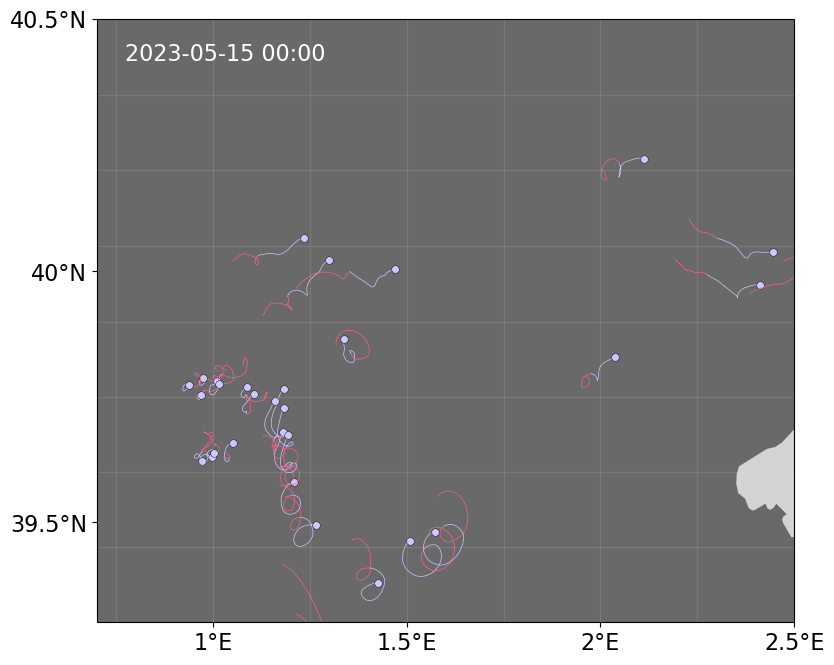

In [126]:
for itime,time in enumerate(time_plots):
    # if itime!=5:
    #     continue

    plt.close()
    fig = plt.figure(figsize=(9,9))

    ax = fig.add_subplot(1,1,1,projection=ccrs.Mercator())
    #ax.add_feature(cfeature.GSHHSFeature(scale='h',facecolor='gainsboro',linewidth=0.5))
    ax.add_feature(cfeature.LAND,facecolor='lightgrey')
    ax.add_feature(cfeature.OCEAN,facecolor='dimgrey')
    # Set ticks
    ax.set_xticks(np.arange(-130,110,0.5), crs=crs_data)
    ax.set_yticks(np.arange(30,50,0.5), crs=crs_data)
    ax.tick_params(axis='x',which='both',bottom=True,top=False,labelbottom=True,labelsize=labelsz)
    ax.tick_params(axis='y',which='both',left=True,right=False,labelleft=True,labelsize=labelsz)
    lon_formatter = LongitudeFormatter(zero_direction_label=True)
    lat_formatter = LatitudeFormatter()
    ax.xaxis.set_major_formatter(lon_formatter)
    ax.yaxis.set_major_formatter(lat_formatter)
    # Plot extent
    ax.set_extent([0.7,2.5,39.3,40.5], crs_data)
    ax.gridlines(crs=crs_data,linewidth=1,color='white', alpha=0.1, linestyle='-')
    ax.text(0.04,0.93,time.strftime('%Y-%m-%d %H:%M'),fontsize=labelsz,transform=ax.transAxes,color='w')

    for idrifter in drifters.i.unique():
        drifter = drifters[drifters.i == idrifter]

        tail1 = drifter[(drifter.index>=time-tail_window) & (drifter.index<=time)]
        tail2 = drifter[(drifter.index>=time-tail_window*2) & (drifter.index<=time-tail_window)]
        #tail3 = drifter[(drifter.index>=time-tail_window*3) & (drifter.index<=time-tail_window*2)]

        lw = 0.5
        ax.plot(tail1.LON,tail1.LAT,
            color='#CBC7FF',linewidth=lw,
            transform=crs_data)

        ax.plot(tail2.LON,tail2.LAT,
            color='#FA608E',linewidth=lw,
            transform=crs_data)

        # ax.plot(tail3.LON,tail3.LAT,
        #     color='#4D3C61',linewidth=lw,
        #     transform=crs_data)


        drifter_current = drifter[drifter.index == time]
        ax.scatter(drifter_current.LON,drifter_current.LAT,
            s=30, c='#CBC7FF', edgecolors='k', linewidths=0.3,
            zorder=2,
            transform=crs_data)

    img_name = f'fast_swot_drifter_trajectories_{tail_h}h_{time.strftime("%Y%m%d%H%M")}.png'
    img_path = os.path.join(path_images,'git_nosync','trajectories',img_name)        
    
    plt.savefig(img_path,bbox_inches='tight',dpi=200)


In [127]:
# Create list of filenames for the images
image_files = sorted(glob(os.path.join(path_images,'git_nosync','trajectories','*')))

# Read images and save as GIF
fname = f'fast_swot_drifter_trajectories_{tail_h}h.gif'
fpath = os.path.join(path_images,fname)
with imageio.get_writer(fpath, mode='I', duration=0.1, loop=0) as writer:
    for filename in image_files:
        image = imageio.imread(filename)
        writer.append_data(image)